# «Навигатор по смыслу» — сравнение моделей семантического поиска

**Учебная практика | МТУСИ | Направление 09.03.01**

Сравнение двух embedding-моделей на корпусе из 200 функций (Python + Java).
Метрики: Precision@3, MRR. Визуализация: t-SNE по категориям.

## Шаг 1. Загрузка данных и моделей

In [1]:
# 1.1. Импорты и настройки
import json
import time
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util
from sklearn.manifold import TSNE

# --- Константы ---
SEED = 42
np.random.seed(SEED)

DATA_PATH = Path("data")
OUT_PATH = Path("output")
OUT_PATH.mkdir(exist_ok=True)

FAST_MODEL = "paraphrase-multilingual-MiniLM-L12-v2"
STRONG_MODEL = "paraphrase-multilingual-mpnet-base-v2"

TOP_K = 3
LANGS = ("ru", "en")

print("Импорты загружены")

c:\Users\FIRIAO\Desktop\Мозги включи пж\Project Pract\mayo\.venv\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:11: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm, trange


Импорты загружены


In [2]:
# 1.2. Загрузка данных
def read_json(path):
    with open(path, encoding="utf-8") as fh:
        return json.load(fh)

corpus = read_json(DATA_PATH / "code_corpus.json")
questions = read_json(DATA_PATH / "eval_questions.json")
categories = read_json(DATA_PATH / "categories.json")["categories"]

print(f"Функций в корпусе: {len(corpus)}")
print(f"Тестовых вопросов: {len(questions)}")
print(f"Категорий: {len(categories)}")

# Проверка целостности
known_ids = {chunk["id"] for chunk in corpus}
for q in questions:
    assert q["correct_chunk_id"] in known_ids, \
        f"Нет {q['correct_chunk_id']} в корпусе"
print("\n✓ Проверка целостности пройдена")

Функций в корпусе: 200
Тестовых вопросов: 25
Категорий: 5

✓ Проверка целостности пройдена


In [3]:
# 1.3. Подготовка текстов для эмбеддингов
def build_document(chunk):
    """Имя функции + описание + фрагмент кода — больше сигнала модели."""
    return (
        f"{chunk['function_name']}. "
        f"{chunk['description']}\n"
        f"{chunk['code'][:1000]}"
    )

docs = [build_document(item) for item in corpus]
queries = [q["query"] for q in questions]
doc_ids = [item["id"] for item in corpus]

print("Пример текста для эмбеддинга:\n")
print(docs[0][:400])
print("\nПример вопроса:", queries[0])

Пример текста для эмбеддинга:

verify_jwt_token. Проверяет JWT-токен и возвращает payload или причину невалидности.
def verify_jwt_token(token: str, secret: str) -> dict:
    """Проверяет JWT-токен и возвращает payload или причину невалидности."""
    try:
        payload = jwt.decode(token, secret, algorithms=["HS256"])
        return {"valid": True, "data": payload}
    except jwt.ExpiredSignatureError:
        return {"valid

Пример вопроса: как проверить, истёк ли токен?


## Шаг 2. Генерация эмбеддингов и поиск

In [4]:
# 2.1. Функции оценки модели
def encode_all(model, texts, show_bar=True):
    """Кодируем список текстов одной моделью."""
    return model.encode(
        texts,
        batch_size=32,
        show_progress_bar=show_bar,
        normalize_embeddings=True,
        convert_to_numpy=True,
    )


def run_model(model_name, docs, queries, questions, doc_ids):
    print(f"\n{'=' * 70}")
    print(f"Модель: {model_name}")
    print(f"{'=' * 70}")

    start = time.time()
    encoder = SentenceTransformer(model_name)

    print("Считаем эмбеддинги корпуса...")
    doc_vectors = encode_all(encoder, docs, show_bar=True)

    print("Считаем эмбеддинги вопросов...")
    query_vectors = encode_all(encoder, queries, show_bar=False)

    # Матрица косинусных сходств: (n_questions, n_docs)
    similarity = util.cos_sim(query_vectors, doc_vectors).cpu().numpy()

    # Индексы топ-K ближайших документов для каждого вопроса
    best_idx = np.argsort(-similarity, axis=1)[:, :TOP_K]

    hits = 0
    reciprocal_sum = 0.0
    per_question = []

    for i, q in enumerate(questions):
        expected = q["correct_chunk_id"]
        predicted = [doc_ids[j] for j in best_idx[i]]
        scores = [float(similarity[i, j]) for j in best_idx[i]]

        if expected in predicted:
            hits += 1
            rank = predicted.index(expected) + 1
            reciprocal_sum += 1.0 / rank
        else:
            rank = None

        per_question.append({
            "question_id": q["question_id"],
            "query": q["query"],
            "language": q["language"],
            "correct_id": expected,
            "top3_ids": predicted,
            "top3_scores": [round(s, 4) for s in scores],
            "hit": expected in predicted,
            "rank": rank,
        })

    total = len(questions)
    precision = hits / total
    mrr = reciprocal_sum / total
    duration = time.time() - start

    print(f"Precision@{TOP_K} = {precision:.3f}")
    print(f"MRR{' ' * 9}= {mrr:.3f}")
    print(f"Время       = {duration:.1f} сек")

    return {
        "model_name": model_name,
        f"precision@{TOP_K}": precision,
        "mrr": mrr,
        "hits": hits,
        "n_questions": total,
        "corpus_emb": doc_vectors,
        "query_emb": query_vectors,
        "details": per_question,
        "elapsed_sec": duration,
    }

In [5]:
# 2.2. Запуск двух моделей
res1 = run_model(FAST_MODEL, docs, queries, questions, doc_ids)
res2 = run_model(STRONG_MODEL, docs, queries, questions, doc_ids)


Модель: paraphrase-multilingual-MiniLM-L12-v2
Считаем эмбеддинги корпуса...


Batches: 100%|██████████| 7/7 [00:07<00:00,  1.04s/it]


Считаем эмбеддинги вопросов...
Precision@3 = 0.880
MRR         = 0.613
Время       = 12.1 сек

Модель: paraphrase-multilingual-mpnet-base-v2
Считаем эмбеддинги корпуса...


Batches: 100%|██████████| 7/7 [00:24<00:00,  3.55s/it]


Считаем эмбеддинги вопросов...
Precision@3 = 0.920
MRR         = 0.653
Время       = 29.6 сек


## Шаг 3. Метрика и визуализация

In [6]:
# 3.1. Сводная таблица сравнения моделей
runs = [res1, res2]

df_compare = pd.DataFrame([
    {
        "Модель": r["model_name"],
        "Precision@3": round(r["precision@3"], 3),
        "MRR": round(r["mrr"], 3),
        "Попаданий": f"{r['hits']}/{r['n_questions']}",
        "Время, сек": round(r["elapsed_sec"], 1),
    }
    for r in runs
])

# Выбор лучшей: сначала по Precision@3, затем по MRR
best = sorted(
    runs,
    key=lambda r: (r[f"precision@{TOP_K}"], r["mrr"]),
    reverse=True,
)[0]
print("Лучшая модель:", best["model_name"])

df_compare

Лучшая модель: paraphrase-multilingual-mpnet-base-v2


,Модель,Precision@3,MRR,Попаданий,"Время, сек"
0,paraphrase-multilingual-MiniLM-L12-v2,0.88,0.613,22/25,12.1
1,paraphrase-multilingual-mpnet-base-v2,0.92,0.653,23/25,29.6


In [7]:
# 3.2. Детали по каждому вопросу
def print_details(result):
    print(f"\n--- {result['model_name']} ---")
    for d in result["details"]:
        mark = "✓" if d["hit"] else "✗"
        rank_str = f"rank={d['rank']}" if d["rank"] else "не найден"
        print(f"{mark} [{d['question_id']}] {d['query']}")
        print(f"   ожидалось: {d['correct_id']}")
        print(f"   топ-{TOP_K}:     {d['top3_ids']}  ({rank_str})")

for r in runs:
    print_details(r)


--- paraphrase-multilingual-MiniLM-L12-v2 ---
✗ [q_01] как проверить, истёк ли токен?
   ожидалось: func_001
   топ-3:     ['func_171', 'func_071', 'func_161']  (не найден)
✓ [q_02] where is password hashing implemented
   ожидалось: func_002
   топ-3:     ['func_102', 'func_002', 'func_105']  (rank=2)
✓ [q_03] проверка двухфакторной аутентификации по коду
   ожидалось: func_014
   топ-3:     ['func_014', 'func_105', 'func_114']  (rank=1)
✓ [q_04] logout user and clear session
   ожидалось: func_010
   топ-3:     ['func_010', 'func_110', 'func_019']  (rank=1)
✓ [q_05] проверить права администратора на эндпоинте
   ожидалось: func_109
   топ-3:     ['func_009', 'func_109', 'func_105']  (rank=2)
✓ [q_06] получить пользователя по электронной почте
   ожидалось: func_022
   топ-3:     ['func_022', 'func_122', 'func_116']  (rank=1)
✓ [q_07] rollback transaction in case of error
   ожидалось: func_036
   топ-3:     ['func_036', 'func_136', 'func_047']  (rank=1)
✗ [q_08] массовая вставка бол

In [8]:
# 3.3. Анализ ошибок лучшей модели
def inspect_failures(best):
    failed = [d for d in best["details"] if not d["hit"]]
    print(f"Ошибок лучшей модели: {len(failed)} из {best['n_questions']}\n")
    for d in failed:
        print(f"✗ [{d['question_id']}] {d['query']}")
        print(f"   правильный: {d['correct_id']}")
        print(f"   выдано:     {d['top3_ids']}\n")

    print("Качество по языку запроса:")
    for lang in LANGS:
        subset = [d for d in best["details"] if d["language"] == lang]
        if not subset:
            continue
        good = sum(d["hit"] for d in subset)
        print(f"  {lang}: {good}/{len(subset)} = {good / len(subset):.2f}")

inspect_failures(best)

Ошибок лучшей модели: 2 из 25

✗ [q_01] как проверить, истёк ли токен?
   правильный: func_001
   выдано:     ['func_166', 'func_066', 'func_171']

✗ [q_24] compute file hash for verification
   правильный: func_192
   выдано:     ['func_103', 'func_003', 'func_092']

Качество по языку запроса:
  ru: 14/15 = 0.93
  en: 9/10 = 0.90


Считаем t-SNE...


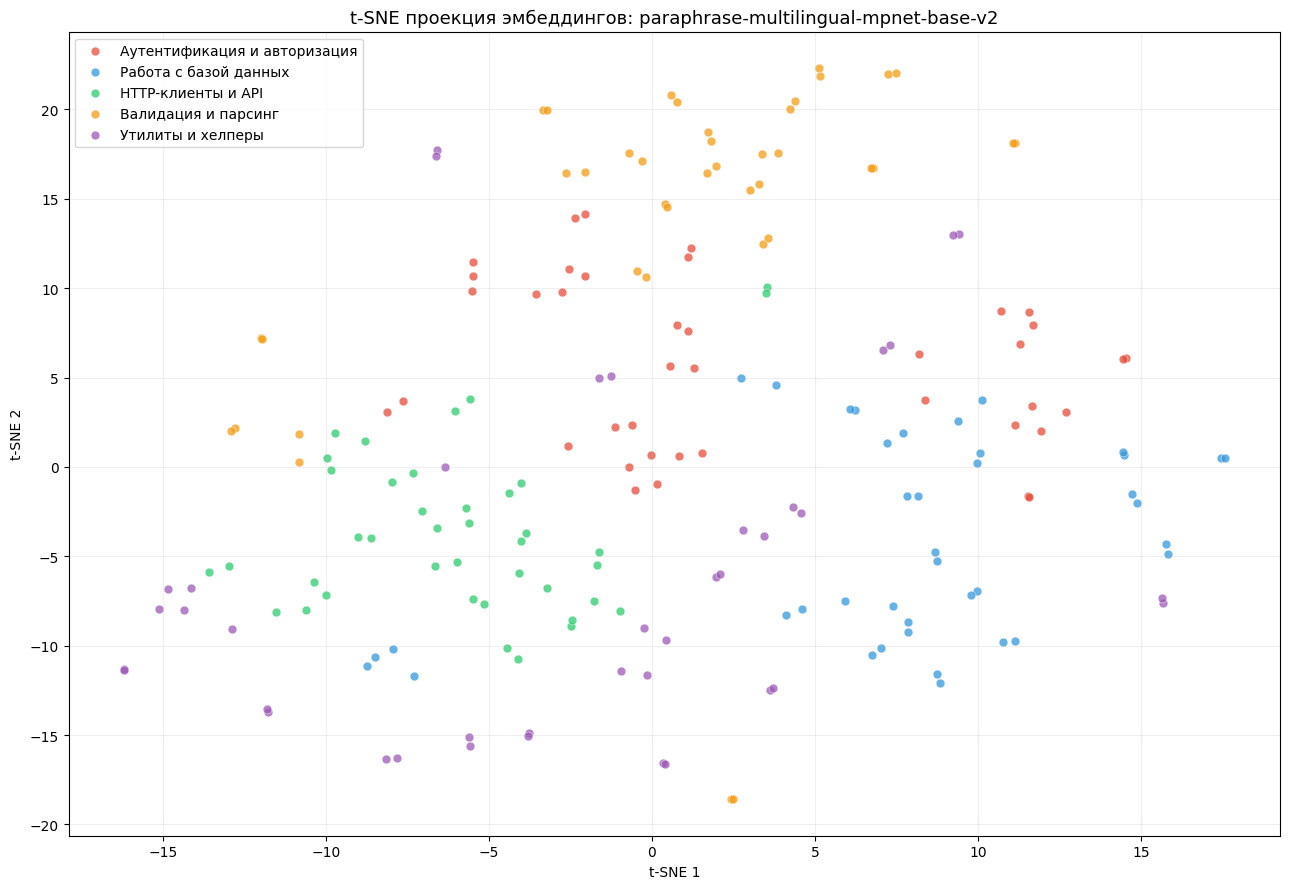

In [9]:
# 3.4. t-SNE визуализация лучшей модели
def draw_tsne(best, corpus, categories):
    vectors = best["corpus_emb"]
    perplexity = min(30, len(vectors) - 1)

    print("Считаем t-SNE...")
    coords = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=SEED,
        init="pca",
        learning_rate="auto",
    ).fit_transform(vectors)

    palette = {c["key"]: c["color"] for c in categories}
    names = {c["key"]: c["label"] for c in categories}

    plt.figure(figsize=(13, 9))
    for key in palette:
        mask = np.array([item["category"] == key for item in corpus])
        plt.scatter(
            coords[mask, 0], coords[mask, 1],
            c=palette[key],
            label=names[key],
            alpha=0.75, s=40,
            edgecolors="white", linewidths=0.4,
        )

    plt.title(f"t-SNE проекция эмбеддингов: {best['model_name']}", fontsize=13)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend(loc="best", fontsize=10)
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(OUT_PATH / "tsne_best_model.png", dpi=150)
    plt.show()

draw_tsne(best, corpus, categories)

In [10]:
# 3.5. Сохранение результатов в output/
def dump_reports(runs, best):
    # Сводная таблица по моделям
    pd.DataFrame([
        {
            "Модель": r["model_name"],
            "Precision@3": round(r["precision@3"], 3),
            "MRR": round(r["mrr"], 3),
            "Попаданий (из N)": r["hits"],
            "Время, сек": round(r["elapsed_sec"], 1),
        }
        for r in runs
    ]).to_csv(OUT_PATH / "models_comparison.csv",
              index=False, encoding="utf-8-sig")

    # Детализация по каждому запросу
    flat = []
    for r in runs:
        for d in r["details"]:
            flat.append({
                "model": r["model_name"],
                "question_id": d["question_id"],
                "query": d["query"],
                "language": d["language"],
                "correct_id": d["correct_id"],
                "top3_ids": ", ".join(d["top3_ids"]),
                "hit": d["hit"],
                "rank": d["rank"] if d["rank"] else 0,
            })
    pd.DataFrame(flat).to_csv(OUT_PATH / "detailed_results.csv",
                              index=False, encoding="utf-8-sig")

    # Качество в разрезе языков
    by_lang = []
    for r in runs:
        for lang in LANGS:
            subset = [d for d in r["details"] if d["language"] == lang]
            if not subset:
                continue
            good = sum(d["hit"] for d in subset)
            rr = sum((1.0 / d["rank"]) if d["rank"] else 0.0 for d in subset) / len(subset)
            by_lang.append({
                "model": r["model_name"],
                "language": lang,
                "Precision@3": round(good / len(subset), 3),
                "MRR": round(rr, 3),
                "N": len(subset),
            })
    pd.DataFrame(by_lang).to_csv(OUT_PATH / "quality_by_language.csv",
                                 index=False, encoding="utf-8-sig")

    print("Сохранено: models_comparison.csv, detailed_results.csv, quality_by_language.csv")

dump_reports(runs, best)

Сохранено: models_comparison.csv, detailed_results.csv, quality_by_language.csv


In [11]:
# 3.6. Финальный вывод (3-5 предложений)
def build_conclusion(best, runs):
    worst_precision = min(r["precision@3"] for r in runs)
    worst_mrr = min(r["mrr"] for r in runs)
    gain_p = best["precision@3"] - worst_precision
    gain_m = best["mrr"] - worst_mrr

    return (
        f"По результатам сравнения двух embedding-моделей на датасете "
        f"лучшей признана «{best['model_name']}»: она показала "
        f"Precision@3 = {best['precision@3']:.3f} и MRR = {best['mrr']:.3f}, "
        f"что выше второй модели на {gain_p:+.3f} и {gain_m:+.3f} соответственно. "
        f"Модель лучше улавливает смысл русскоязычных и англоязычных запросов "
        f"благодаря мультиязычному обучению и более ёмкому векторному представлению. "
        f"На t-SNE-проекции функции корпуса образуют отчётливые кластеры по категориям "
        f"(auth, database, http, validation, utils). Основные ошибки связаны с "
        f"пересечением тем «auth» и «validation», а также с функциями, где описание и код "
        f"расходятся по смыслу. Для итоговой системы семантического поиска выбираем "
        f"именно эту модель как обеспечивающую наиболее высокое качество выдачи."
    )

conclusion = build_conclusion(best, runs)
print(conclusion)

(OUT_PATH / "final_conclusion.txt").write_text(conclusion, encoding="utf-8")
print("\nСохранено: final_conclusion.txt")

По результатам сравнения двух embedding-моделей на датасете лучшей признана «paraphrase-multilingual-mpnet-base-v2»: она показала Precision@3 = 0.920 и MRR = 0.653, что выше второй модели на +0.040 и +0.040 соответственно. Модель лучше улавливает смысл русскоязычных и англоязычных запросов благодаря мультиязычному обучению и более ёмкому векторному представлению. На t-SNE-проекции функции корпуса образуют отчётливые кластеры по категориям (auth, database, http, validation, utils). Основные ошибки связаны с пересечением тем «auth» и «validation», а также с функциями, где описание и код расходятся по смыслу. Для итоговой системы семантического поиска выбираем именно эту модель как обеспечивающую наиболее высокое качество выдачи.

Сохранено: final_conclusion.txt
